In [2]:
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats
import os
from torchvision.datasets import ImageFolder

In [3]:
plt.rcParams.update({
    "font.family": "Courier New",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "figure.titlesize": 20
})

In [4]:
dataset = ImageFolder("/srv/defectDetectionDataset/surfaceClassification/baseline")

In [5]:
targets = np.array(dataset.targets)
num_classes = len(dataset.classes)
labels =["Bent",
  "Blackstained",
  "Cracked",
  "GapDemo",
  "MissingEnd",
  "NoDeficiencies",
  "Rust",
  "ScratchedSurface",
  "Silicatestain",
  "UnknownStains",
  "Unknown",
  "Waterstains"]

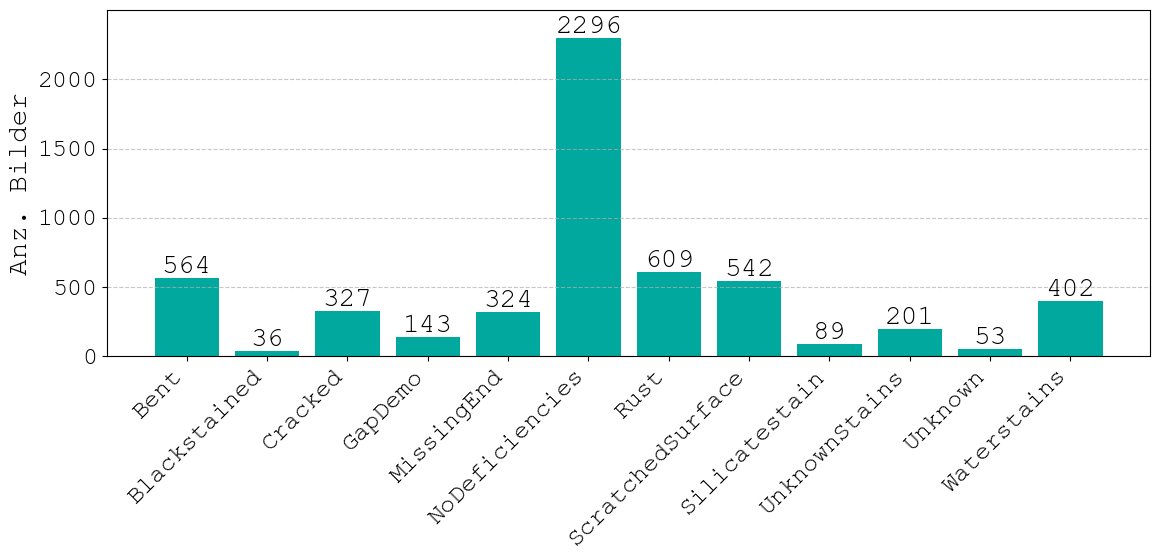

In [6]:
plt.rcParams.update({
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

fig = plt.figure(figsize=(12, 6))

plt.bar(np.arange(0, num_classes), [np.sum(targets == i) for i in range(num_classes)], color=(0.0, 0.66, 0.62))
for i in range(num_classes):
    plt.text(i, np.sum(targets == i), str(np.sum(targets == i)), ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(np.arange(0, 2500, 500))
plt.ylim(0, 2500)
plt.xticks(np.arange(0, num_classes), labels, rotation=45, ha='right')
plt.ylabel("Anz. Bilder")
plt.tight_layout()
plt.savefig("plots/class_distribution_old.pdf", bbox_inches='tight')
plt.show()

## New class distribution in noisy and fully cleaned

In [7]:
noisy_dataset = ImageFolder("/srv/defectDetectionDataset/surfaceClassification/noisy")

In [8]:
noisy_targets = np.array(noisy_dataset.targets)
noisy_num_classes = len(noisy_dataset.classes)
labels =[
    "background",
    "black_stain",
    "corrosion",
    "crack",
    "deformation",
    "missing_part",
    "ok",
    "other",
    "silicate_stain",
    "water_stain"]

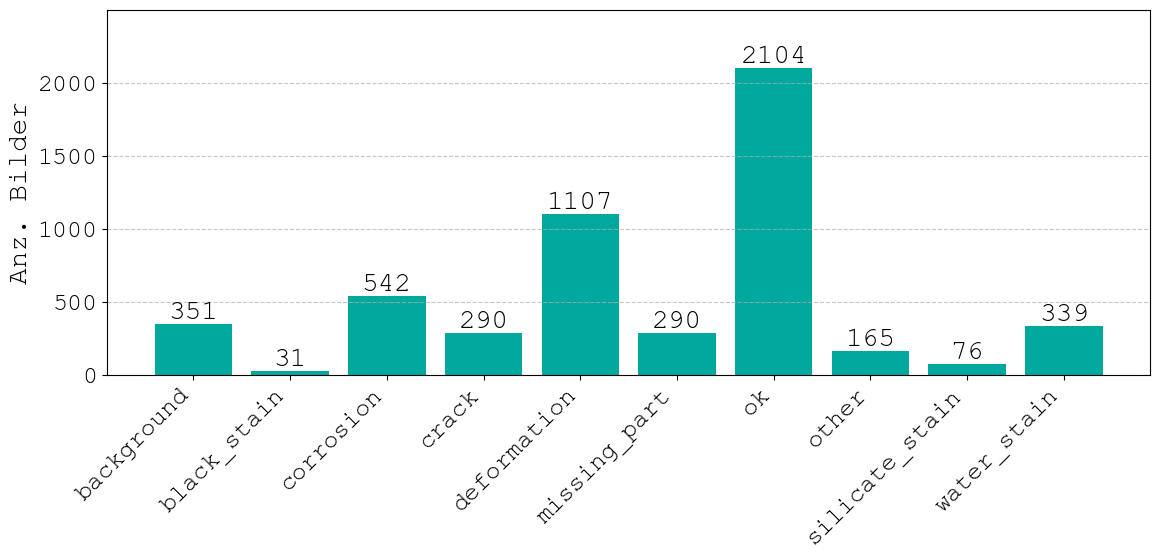

In [9]:
fig = plt.figure(figsize=(12, 6))

plt.bar(np.arange(0, noisy_num_classes), [np.sum(noisy_targets == i) for i in range(noisy_num_classes)], color=(0.0, 0.66, 0.62))
for i in range(noisy_num_classes):
    plt.text(i, np.sum(noisy_targets == i), str(np.sum(noisy_targets == i)), ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(np.arange(0, 2500, 500))
plt.ylim(0, 2500)
plt.xticks(np.arange(0, noisy_num_classes), labels, rotation=45, ha='right')
plt.ylabel("Anz. Bilder")
plt.tight_layout()
plt.savefig("plots/class_distribution_noisy.pdf", bbox_inches='tight')
plt.show()

In [10]:
clean_dataset = ImageFolder("/srv/defectDetectionDataset/surfaceClassification/full_clean")

In [11]:
clean_targets = np.array(clean_dataset.targets)
clean_num_classes = len(clean_dataset.classes)
labels =[
    "background",
    "black_stain",
    "corrosion",
    "crack",
    "deformation",
    "missing_part",
    "ok",
    "other",
    "silicate_stain",
    "water_stain"]

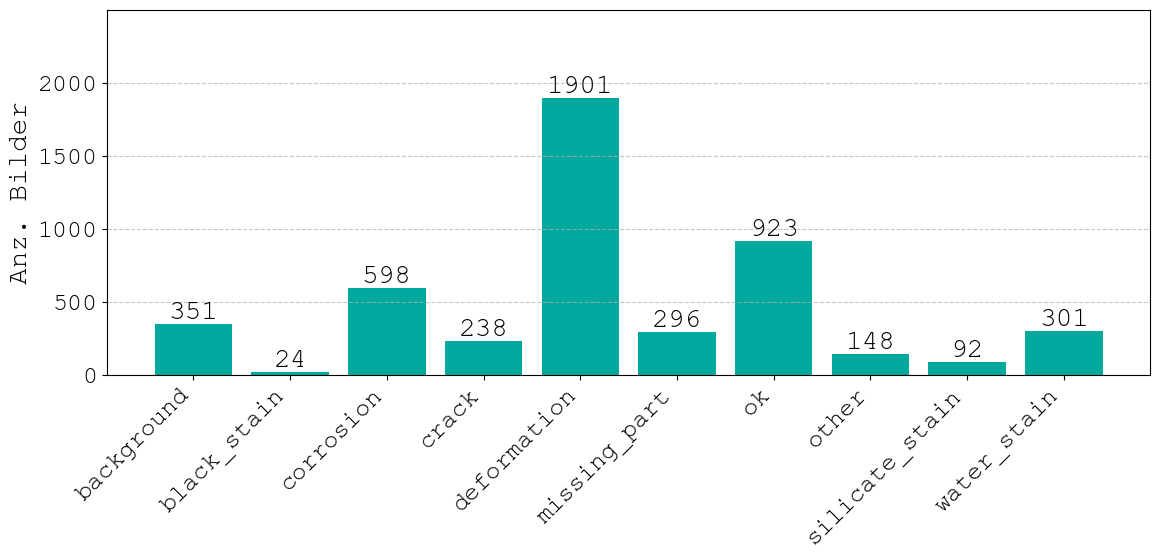

In [12]:
fig = plt.figure(figsize=(12, 6))

plt.bar(np.arange(0, clean_num_classes), [np.sum(clean_targets == i) for i in range(clean_num_classes)], color=(0.0, 0.66, 0.62))
for i in range(clean_num_classes):
    plt.text(i, np.sum(clean_targets == i), str(np.sum(clean_targets == i)), ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(np.arange(0, 2500, 500))
plt.ylim(0, 2500)
plt.xticks(np.arange(0, clean_num_classes), labels, rotation=45, ha='right')
plt.ylabel("Anz. Bilder")
plt.tight_layout()
plt.savefig("plots/class_distribution_clean.pdf", bbox_inches='tight')
plt.show()

## Noise estimation through confusion matrix

In [13]:
from os import path
from PIL import Image
from hashlib import md5
import pandas as pd

noisy_images = []
for img_path, _ in noisy_dataset.samples:
    label = path.basename(path.dirname(img_path))
    img = Image.open(img_path)
    image_id = md5(img.tobytes()).hexdigest()
    noisy_images.append({"id": image_id, "label": label})

noisy_df = pd.DataFrame(noisy_images)

In [14]:
clean_images = []
for img_path, _ in clean_dataset.samples:
    label = path.basename(path.dirname(img_path))
    img = Image.open(img_path)
    image_id = md5(img.tobytes()).hexdigest()
    clean_images.append({"id": image_id, "label": label})

clean_df = pd.DataFrame(clean_images)

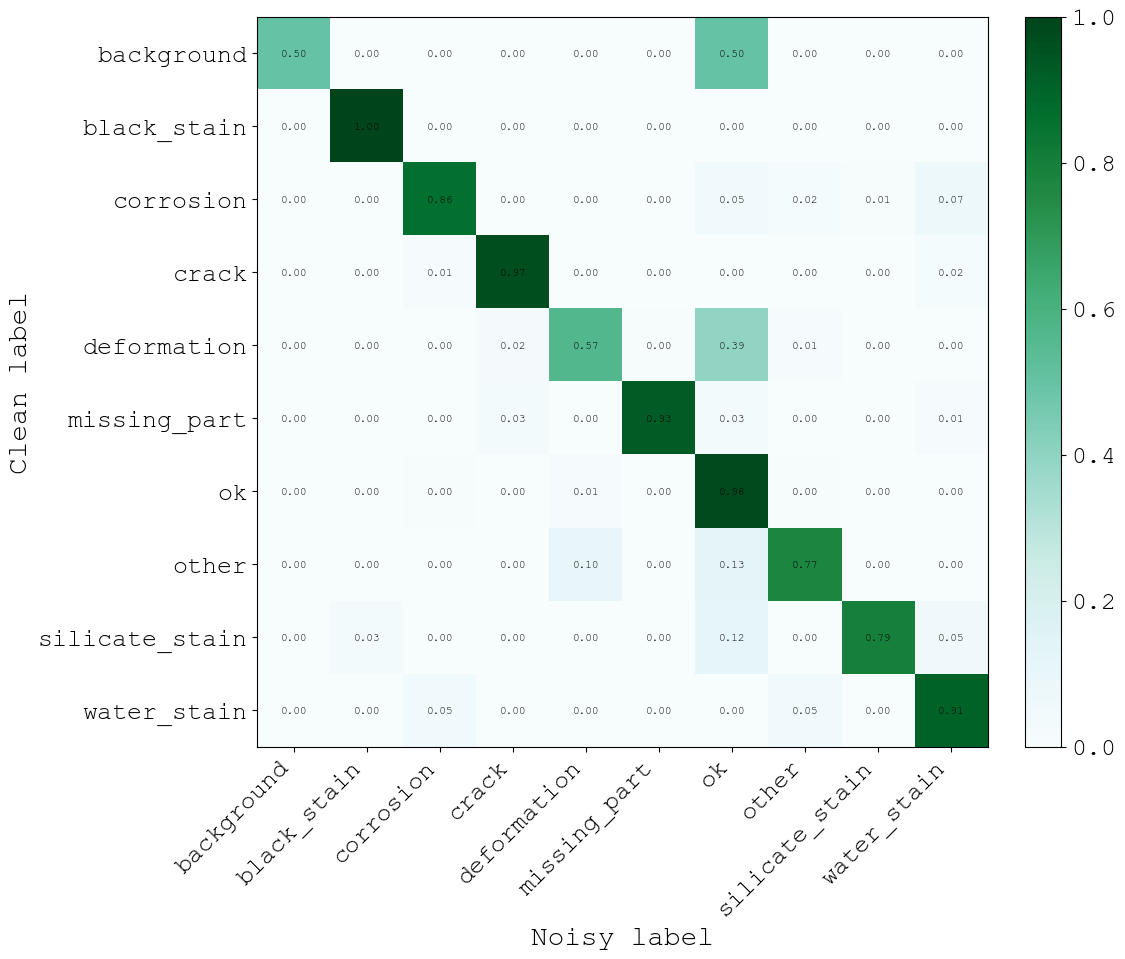

noisy,background,black_stain,corrosion,crack,deformation,missing_part,ok,other,silicate_stain,water_stain
clean,,,,,,,,,,
background,351,0,0,0,2,0,350,0,0,0
black_stain,0,24,0,0,0,0,0,0,0,0
corrosion,0,2,513,0,0,0,29,11,3,40
crack,0,0,3,238,0,0,0,0,0,4
deformation,0,0,5,43,1079,9,753,20,0,0
missing_part,0,0,0,8,0,278,10,0,0,4
ok,0,0,4,0,11,0,904,4,0,0
other,0,0,0,0,15,0,19,114,0,0
silicate_stain,0,3,0,0,0,0,11,0,73,5


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Align noisy and clean labels by image id
merged_df = noisy_df.merge(clean_df, on="id", how="inner", suffixes=("_noisy", "_clean"))
if merged_df.empty:
    raise ValueError("No overlapping image ids between noisy_df and clean_df.")

# Confusion matrix: clean (rows) vs noisy (cols)
labels = sorted(set(merged_df["label_clean"]) | set(merged_df["label_noisy"]))
conf_counts = pd.crosstab(
    merged_df["label_clean"],
    merged_df["label_noisy"],
    rownames=["clean"],
    colnames=["noisy"],
    dropna=False,
).reindex(index=labels, columns=labels, fill_value=0)

# Row-normalized confusion matrix (noise rates)
conf_rates = conf_counts.div(conf_counts.sum(axis=1).replace(0, np.nan), axis=0)

fig, ax = plt.subplots(figsize=(1.2 * len(labels), 1.0 * len(labels)))
im = ax.imshow(conf_rates.values, cmap="BuGn")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Noisy label")
ax.set_ylabel("Clean label")

# Annotate with rates
for i in range(len(labels)):
    for j in range(len(labels)):
        val = conf_rates.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("plots/noise_confusion_matrix.pdf", bbox_inches="tight")
plt.show()

# Also show raw counts for reference
conf_counts

## Baseline performance

In [18]:
baseline_training_statistics = pd.read_csv("../logs/train/SurfaceDefectDetection/baseline/2026-02-20_23-01-25_mobile_s/summary/summary_statistics.csv")
baseline_training_statistics.head()

,metric,mean,median,std,ci_lower,ci_upper,min,max
0,test/f1_macro,0.959773,0.962193,0.012053,0.951151,0.968395,0.940566,0.979609
1,test/precision_macro,0.967116,0.969594,0.010369,0.959699,0.974534,0.945680,0.982018
2,test/recall_macro,0.954355,0.956103,0.014249,0.944162,0.964548,0.926293,0.977574
3,test/acc,0.954355,0.956103,0.014249,0.944162,0.964548,0.926293,0.977574
4,test/f1_weighted,0.965322,0.967824,0.008678,0.959115,0.971530,0.952446,0.976716


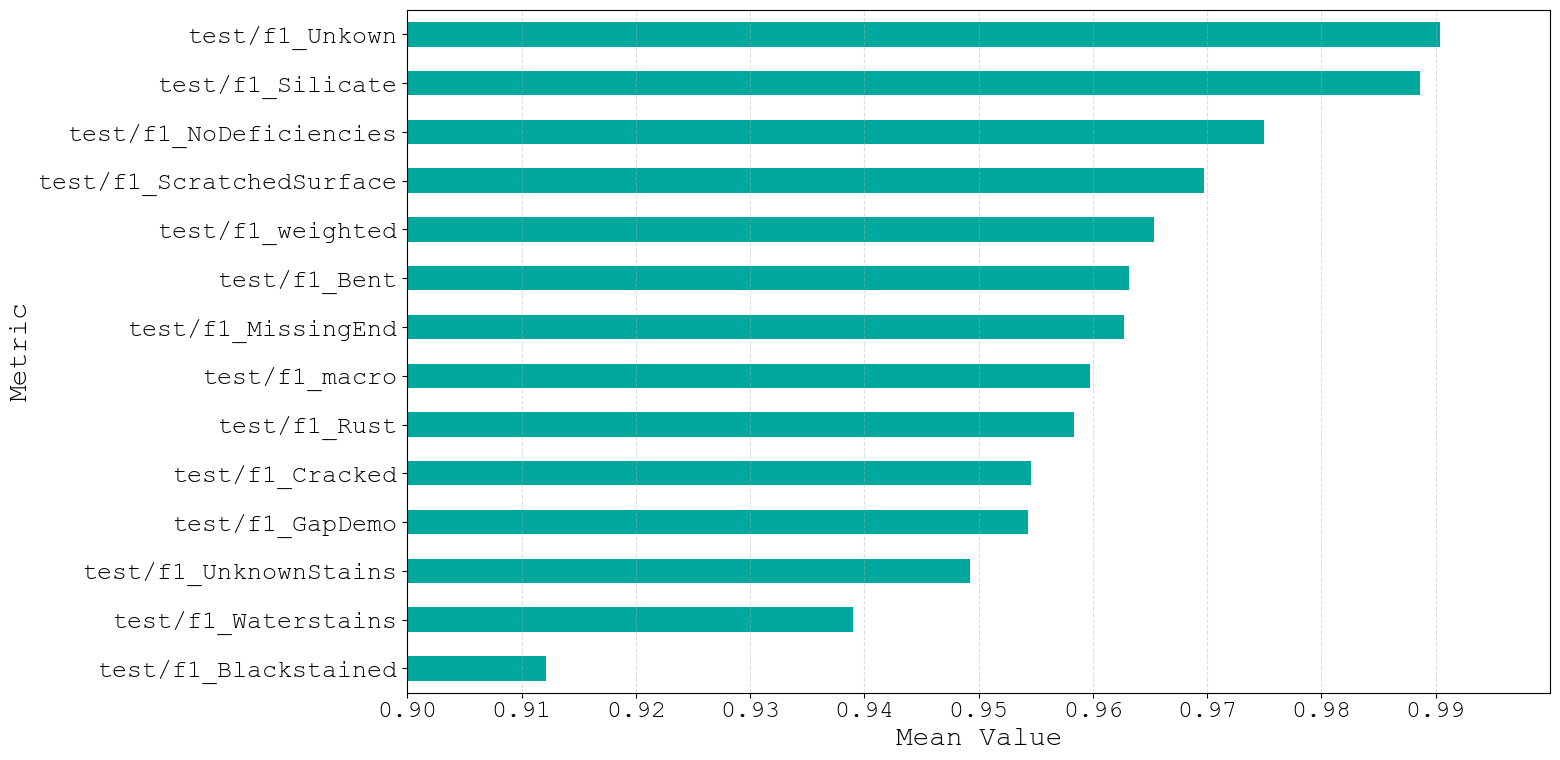

In [41]:
# Mean values for metrics that start with test/f1_
metrics_df = baseline_training_statistics.copy()

f1_df = metrics_df[metrics_df["metric"].astype(str).str.startswith("test/f1_")]
mean_series = f1_df.set_index("metric")["mean"].dropna().sort_values(ascending=True)

ax = mean_series.plot(kind="barh", figsize=(16, 8), legend=False, color=(0.0, 0.66, 0.62))
ax.set_xlabel("Mean Value")
ax.set_ylabel("Metric")
ax.set_xlim(0.9, 1.0)
ax.set_xticks(np.arange(0.9, 1.00, 0.01))
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

In [43]:
baseline_clustered_training_statistics = pd.read_csv("../logs/train/SurfaceDefectDetection/baseline/2026-02-22_08-21-39_mobile_s_clustered/summary/summary_statistics.csv")
baseline_clustered_training_statistics.head()

,metric,mean,median,std,ci_lower,ci_upper,min,max
0,test/f1_macro,0.861887,0.859497,0.021329,0.846629,0.877145,0.827796,0.907903
1,test/precision_macro,0.870318,0.868825,0.026291,0.851510,0.889126,0.838271,0.933226
2,test/recall_macro,0.868280,0.869543,0.020746,0.853439,0.883121,0.823488,0.893364
3,test/acc,0.868280,0.869543,0.020746,0.853439,0.883121,0.823488,0.893364
4,test/f1_weighted,0.874879,0.871633,0.012597,0.865868,0.883890,0.857987,0.897597


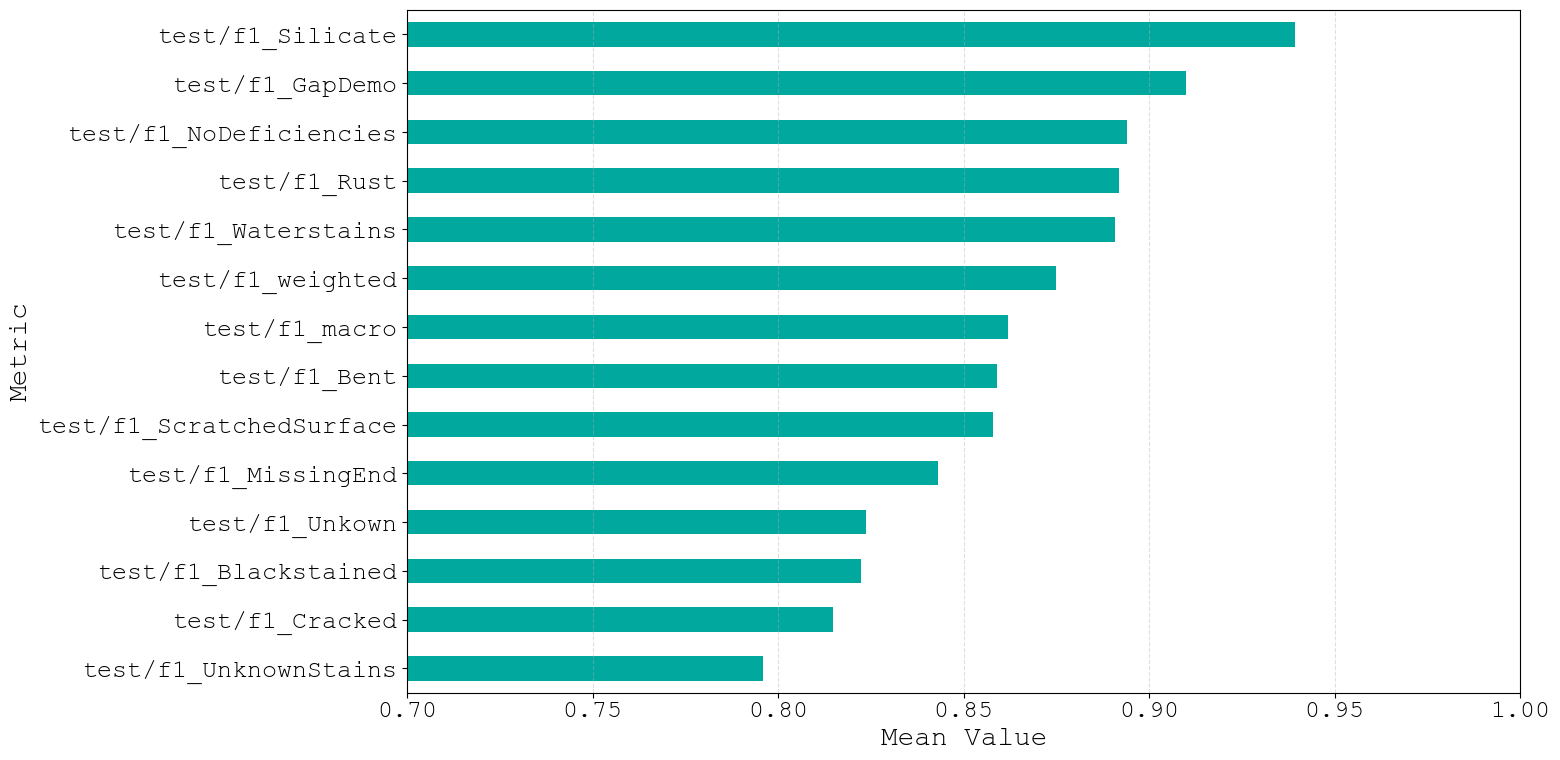

In [48]:
# Mean values for metrics that start with test/f1_
metrics_df = baseline_clustered_training_statistics.copy()

f1_df = metrics_df[metrics_df["metric"].astype(str).str.startswith("test/f1_")]
mean_series = f1_df.set_index("metric")["mean"].dropna().sort_values(ascending=True)

ax = mean_series.plot(kind="barh", figsize=(16, 8), legend=False, color=(0.0, 0.66, 0.62))
ax.set_xlabel("Mean Value")
ax.set_ylabel("Metric")
ax.set_xlim(0.7, 1.0)
ax.set_xticks(np.arange(0.7, 1.00, 0.05))
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()